In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('JNJ','FN'), 
         ('JNJ','KTOS'), 
         ('JNJ','MDGL'), 
         ('MCK','FN'), 
         ('MCK', 'KTOS'),
         ('MCK', 'MDGL'), 
         ('CSCO','FN'), 
         ('CSCO', 'KTOS'), 
         ('CSCO','MDGL')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, 

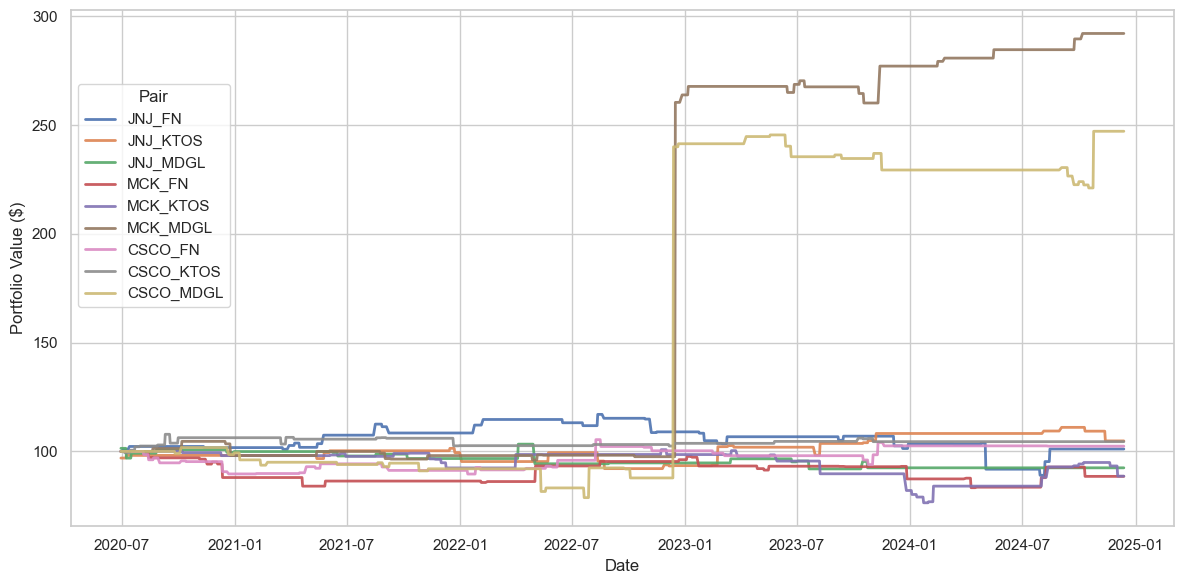

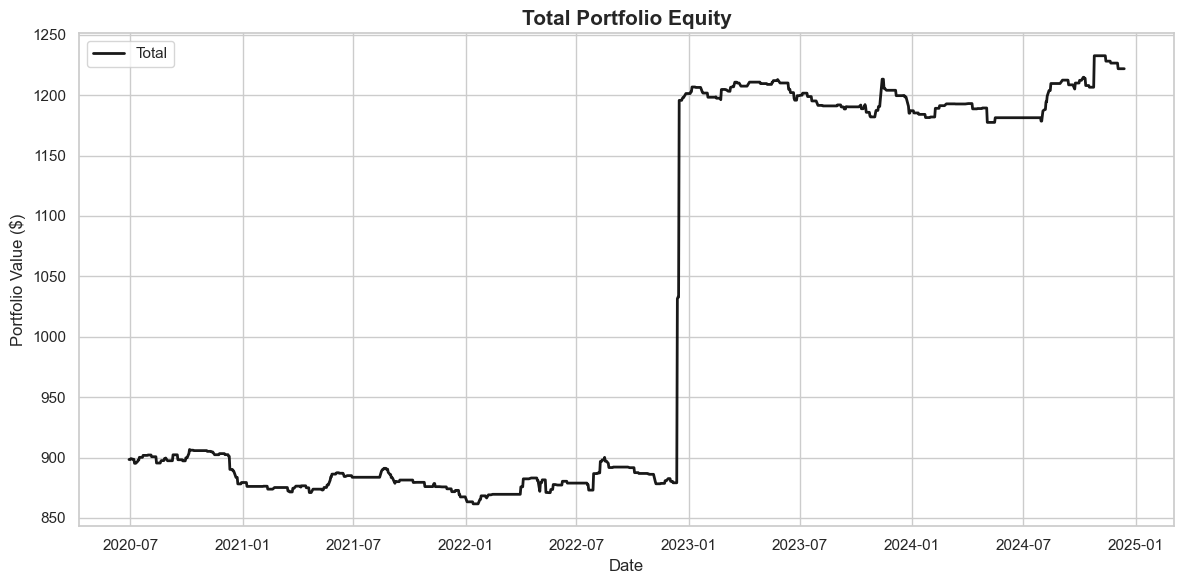

Summary
JNJ_FN: Final Value = $101.11, Total Return = 1.11%, Trades = 38
JNJ_KTOS: Final Value = $104.83, Total Return = 8.13%, Trades = 29
JNJ_MDGL: Final Value = $92.46, Total Return = -8.84%, Trades = 19
MCK_FN: Final Value = $88.53, Total Return = -11.47%, Trades = 30
MCK_KTOS: Final Value = $88.64, Total Return = -11.36%, Trades = 33
MCK_MDGL: Final Value = $292.16, Total Return = 192.16%, Trades = 29
CSCO_FN: Final Value = $102.41, Total Return = 2.41%, Trades = 35
CSCO_KTOS: Final Value = $104.49, Total Return = 4.49%, Trades = 26
CSCO_MDGL: Final Value = $247.20, Total Return = 147.20%, Trades = 36

Total Portfolio Performance
Initial Portfolio Value: $898.37
Final Portfolio Value:   $1,221.83
Total Return:            36.01%

Sharpe Ratios
JNJ_FN: Sharpe Ratio = 0.07
JNJ_KTOS: Sharpe Ratio = 0.27
JNJ_MDGL: Sharpe Ratio = -0.27
MCK_FN: Sharpe Ratio = -0.27
MCK_KTOS: Sharpe Ratio = -0.24
MCK_MDGL: Sharpe Ratio = 0.50
CSCO_FN: Sharpe Ratio = 0.11
CSCO_KTOS: Sharpe Ratio = 0.25
CSC

In [5]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)